In [3]:
import sys
!{sys.executable} -m pip install statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\ravi4\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [6]:
import os
print(os.getcwd())

C:\Users\ravi4\Documents\energy-project-analytics\notebooks


In [7]:
import os
os.chdir(r"C:\Users\ravi4\Documents\energy-project-analytics")
print(os.getcwd())

C:\Users\ravi4\Documents\energy-project-analytics


In [4]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

print("imports OK")

imports OK


In [8]:
# Connect to SQLite
conn = sqlite3.connect("data/energy.db")

# Pull the data we need with a SQL query
query = """
SELECT 
    country,
    CAST(year AS INTEGER) AS year,
    CAST(primary_energy_consumption AS REAL) AS energy_consumption,
    CAST(renewables_share_energy AS REAL) AS renewables_pct,
    CAST(fossil_share_energy AS REAL) AS fossil_pct,
    CAST(gdp AS REAL) AS gdp,
    CAST(population AS REAL) AS population
FROM energy
WHERE country NOT LIKE '%(EIA)%'
  AND country NOT LIKE '%(EI)%'
  AND country NOT LIKE '%(BP)%'
  AND country NOT LIKE '%OECD%'
  AND country NOT LIKE '%OPEC%'
  AND country NOT LIKE '%income%'
  AND country NOT IN (
      'World', 'Asia', 'Europe', 'Africa',
      'North America', 'South America', 'Oceania',
      'European Union (27)', 'Asia Pacific'
  )
  AND primary_energy_consumption != ''
  AND renewables_share_energy != ''
  AND gdp != ''
  AND population != ''
ORDER BY country, year
"""

df = pd.read_sql_query(query, conn)
conn.close()

print(f"Shape: {df.shape}")
print(f"Countries: {df['country'].nunique()}")
print(f"Years: {df['year'].min()} - {df['year'].max()}")
df.head()

Shape: (4294, 7)
Countries: 80
Years: 1965 - 2022


,country,year,energy_consumption,renewables_pct,fossil_pct,gdp,population
0,Algeria,1965,24.833,4.487,95.513,3.566197e+10,12365979.0
1,Algeria,1966,29.833,3.313,96.687,3.393263e+10,12590068.0
2,Algeria,1967,28.247,4.042,95.958,3.709477e+10,12876115.0
3,Algeria,1968,30.345,5.171,94.829,4.142389e+10,13172615.0
4,Algeria,1969,33.539,2.996,97.004,4.538746e+10,13475959.0


In [9]:
# GDP per capita (a better predictor than raw GDP)
df['gdp_per_capita'] = df['gdp'] / df['population']

# Decade column (same logic as SQL Query 7)
df['decade'] = (df['year'] // 10) * 10

# Log of GDP per capita (common in economics — compresses huge range)
df['log_gdp_per_capita'] = np.log(df['gdp_per_capita'])

print("New columns added:")
print(df[['country', 'year', 'gdp_per_capita', 'log_gdp_per_capita', 'decade']].head(10))

New columns added:
   country  year  gdp_per_capita  log_gdp_per_capita  decade
0  Algeria  1965     2883.877915            7.966891    1960
1  Algeria  1966     2695.190688            7.899224    1960
2  Algeria  1967     2880.897744            7.965857    1960
3  Algeria  1968     3144.697242            8.053473    1960
4  Algeria  1969     3368.031837            8.122084    1960
5  Algeria  1970     3623.525405            8.195203    1970
6  Algeria  1971     3241.465365            8.083781    1970
7  Algeria  1972     3832.648580            8.251311    1970
8  Algeria  1973     3865.497790            8.259846    1970
9  Algeria  1974     4002.897726            8.294774    1970


In [10]:
print("=== Summary Statistics ===")
print(df[['renewables_pct', 'fossil_pct', 'gdp_per_capita', 'energy_consumption']].describe().round(2))

=== Summary Statistics ===
       renewables_pct  fossil_pct  gdp_per_capita  energy_consumption
count         4294.00     4294.00         4294.00             4294.00
mean            10.27       86.63        19553.65             1359.18
std             13.73       15.46        16530.53             3705.23
min              0.00       13.87          777.61                0.10
25%              0.94       81.08         7713.59              133.58
50%              4.90       92.11        15071.06              346.41
75%             14.55       98.05        26882.07             1009.80
max             86.13      100.00       163531.40            44516.49


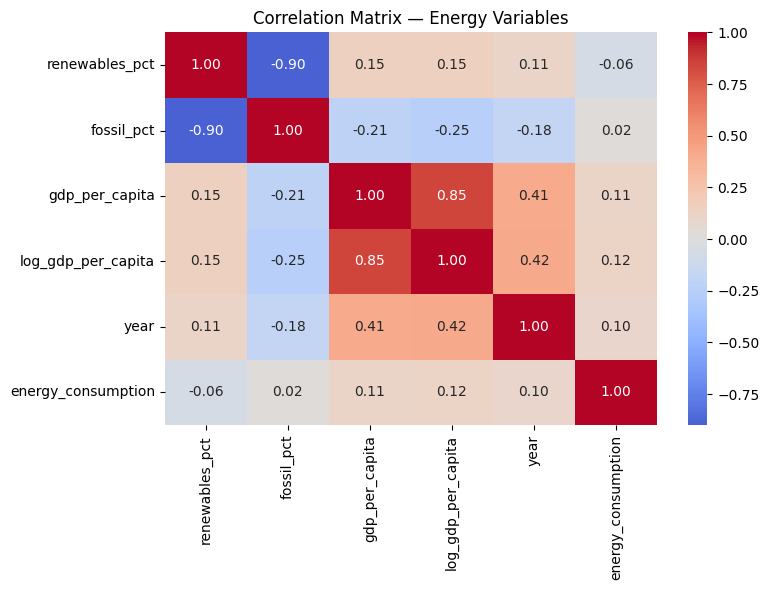

                    renewables_pct  fossil_pct  gdp_per_capita  \
renewables_pct                1.00       -0.90            0.15   
fossil_pct                   -0.90        1.00           -0.21   
gdp_per_capita                0.15       -0.21            1.00   
log_gdp_per_capita            0.15       -0.25            0.85   
year                          0.11       -0.18            0.41   
energy_consumption           -0.06        0.02            0.11   

                    log_gdp_per_capita  year  energy_consumption  
renewables_pct                    0.15  0.11               -0.06  
fossil_pct                       -0.25 -0.18                0.02  
gdp_per_capita                    0.85  0.41                0.11  
log_gdp_per_capita                1.00  0.42                0.12  
year                              0.42  1.00                0.10  
energy_consumption                0.12  0.10                1.00  


In [11]:
# Correlation between our key variables
corr_cols = ['renewables_pct', 'fossil_pct', 'gdp_per_capita', 'log_gdp_per_capita', 'year', 'energy_consumption']
corr_matrix = df[corr_cols].corr().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix — Energy Variables')
plt.tight_layout()
plt.savefig('notebooks/correlation_heatmap.png', dpi=150)
plt.show()

print(corr_matrix)

In [12]:
# Prepare features and target
features = ['log_gdp_per_capita', 'year']
target = 'renewables_pct'

# Drop any remaining NaN rows
model_df = df[features + [target]].dropna()

print(f"Model dataset: {model_df.shape[0]} rows")

# Split into training and test sets (80/20)
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Model dataset: 4294 rows
Train: 3435 rows | Test: 859 rows


In [13]:
# Fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Model Results ===")
print(f"R² score:  {r2:.3f}")
print(f"RMSE:      {rmse:.2f} percentage points")
print()
print("=== Coefficients ===")
for feature, coef in zip(features, model.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"  Intercept: {model.intercept_:.4f}")

=== Model Results ===
R² score:  0.023
RMSE:      14.29 percentage points

=== Coefficients ===
  log_gdp_per_capita: 1.5957
  year: 0.0564
  Intercept: -117.5446


In [14]:
# Add constant for intercept
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Fit OLS model
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Print the full statistical summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:         renewables_pct   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     39.29
Date:                Fri, 01 May 2026   Prob (F-statistic):           1.35e-17
Time:                        12:54:16   Log-Likelihood:                -13785.
No. Observations:                3435   AIC:                         2.758e+04
Df Residuals:                    3432   BIC:                         2.759e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               -117.5446     29